# Clustering and symptom-based time series

This notebook prepares symptom data for time series analysis by cleaning the raw reports, building an individual-level microdataset, and encoding symptoms as dummy variables.

## 1. Data loading and standardization

**Method:** The raw CSV is loaded and each variable is cast to the appropriate type. Identifier columns (`report_id`, `user_id`) are standardized as strings so they are not used as numbers. Date/time columns (`report_created_at`, `report_bad_since`, `data_extracted_at`) are parsed as datetime. Numeric columns (`report_latitude`, `report_longitude`, `syndrome_id`, `report_reviewed`) keep or receive a numeric type. Remaining text columns remain as strings. The analysis period is restricted to **2022-01-01 through 2022-12-01** (January 2022 through December 2022) for the temporal analysis.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/tmp/reports-gds-unb-2022-2024.csv", low_memory=False)

df["report_id"] = df["report_id"].astype(str)
df["user_id"] = df["user_id"].astype(str)
df["report_created_at"] = pd.to_datetime(df["report_created_at"], errors="coerce")
df["report_bad_since"] = pd.to_datetime(df["report_bad_since"], errors="coerce")
df["data_extracted_at"] = pd.to_datetime(df["data_extracted_at"], errors="coerce")
df["report_latitude"] = pd.to_numeric(df["report_latitude"], errors="coerce")
df["report_longitude"] = pd.to_numeric(df["report_longitude"], errors="coerce")

# Build full symptom vocabulary from ALL data (Federal District + with symptoms) BEFORE date filter,
# so we keep the same set of symptom columns (e.g. 42) regardless of analysis period.
def _parse_symptoms(s):
    if pd.isna(s) or not str(s).strip() or str(s).strip() == "[]":
        return []
    out = []
    for line in str(s).splitlines():
        line = line.strip()
        if line.startswith("- "):
            out.append(line[2:].strip())
    return out

_report_sym = df["report_symptoms"].astype(str)
_mask_sym = df["report_symptoms"].notna() & (_report_sym.str.strip() != "") & (_report_sym.str.strip() != "[]") & (_report_sym.str.strip() != "nan")
_mask_fd = df["report_state"] == "Federal District"
_full_symptom_rows = df.loc[_mask_sym & _mask_fd, "report_symptoms"]
all_symptoms_full = sorted(set(s for raw in _full_symptom_rows for s in _parse_symptoms(raw)))

# Restrict to analysis period: 2022-01-01 through 2022-12-01 (by calendar day)
start_date = pd.Timestamp("2022-01-01").normalize()
end_date = pd.Timestamp("2022-12-01").normalize()
df["_date"] = df["report_created_at"].dt.normalize()
df = df[(df["_date"] >= start_date) & (df["_date"] <= end_date)].drop(columns=["_date"]).copy()

df.head()

,report_id,user_id,report_bad_since,report_contact_with_symptom,report_created_at,report_latitude,report_longitude,report_symptoms,syndrome_id,syndrome_description,report_country,report_state,report_city,report_street,report_reviewed,report_traveled_to,data_extracted_at
0,4395232,17369,NaT,NaN,2022-01-01,-15.928432,-47.978894,NaN,NaN,NaN,Brazil,Federal District,Park Way,Estrada Parque Indústria e Abastecimento,NaN,NaN,2025-10-01 23:47:26.379227+00:00
1,4396655,28693,NaT,NaN,2022-01-01,-10.227293,-44.632727,NaN,NaN,NaN,Brazil,Piauí,Parnaguá,Rua Mario Nogueira,NaN,NaN,2025-10-01 23:47:26.379227+00:00
2,4394947,6831,NaT,NaN,2022-01-01,-23.229133,-45.916924,NaN,NaN,NaN,Brazil,São Paulo,São José dos Campos,Rua Rogérias,NaN,NaN,2025-10-01 23:47:26.379227+00:00
3,4394878,20291,NaT,NaN,2022-01-01,-15.992483,-47.993583,NaN,NaN,NaN,Brazil,Federal District,Santa Maria,NaN,NaN,NaN,2025-10-01 23:47:26.379227+00:00
4,4395320,19069,NaT,NaN,2022-01-01,-17.694863,-48.585805,NaN,NaN,NaN,Brazil,Goiás,Caldas Novas,NaN,NaN,NaN,2025-10-01 23:47:26.379227+00:00


In [2]:
# Diagnostic: verificar se, após o filtro de sintomas (FD + com sintomas), o dataset acaba em jul/2024 ou antes.
print("=== Date range diagnostic ===\n")
print("1. Após filtro de datas (2022-01-01 a 2022-12-01):")
print(f"   Linhas: {len(df):,}")
print(f"   report_created_at: min = {df['report_created_at'].min()}, max = {df['report_created_at'].max()}")

_report_sym = df["report_symptoms"].astype(str)
_mask_sym = df["report_symptoms"].notna() & (_report_sym.str.strip() != "") & (_report_sym.str.strip() != "[]") & (_report_sym.str.strip() != "nan")
_mask_fd = df["report_state"] == "Federal District"
subset = df.loc[_mask_sym & _mask_fd]
print("\n2. Após filtro de sintomas (FD + report_symptoms não vazio/[]): dataset do microdataset")
print(f"   Linhas: {len(subset):,}")
if not subset.empty:
    _min, _max = subset['report_created_at'].min(), subset['report_created_at'].max()
    print(f"   report_created_at: min = {_min}, max = {_max}")
    _max_ym = pd.Timestamp(_max).strftime("%Y-%m") if pd.notna(_max) else "N/A"
    acaba_ate_julho2024 = _max_ym <= "2024-07" if _max_ym != "N/A" else False
    print(f"   Dataset acaba em julho/2024 ou antes? {'Sim' if acaba_ate_julho2024 else 'Não'} (max = {_max_ym})")
else:
    print("   (subset vazio — só há sintomas vazios [] no FD)")
    print("   Dataset acaba em julho/2024 ou antes? N/A (sem dados com sintomas)")
print("\n→ Se passo 2 termina antes de dez/2024, o corte vem do filtro FD+sintomas (dados com sintomas param antes).")

=== Date range diagnostic ===

1. Após filtro de datas (2022-01-01 a 2022-12-01):
   Linhas: 1,065,488
   report_created_at: min = 2022-01-01 00:00:00, max = 2022-12-01 00:00:00

2. Após filtro de sintomas (FD + report_symptoms não vazio/[]): dataset do microdataset
   Linhas: 9,052
   report_created_at: min = 2022-01-01 00:00:00, max = 2022-12-01 00:00:00
   Dataset acaba em julho/2024 ou antes? Sim (max = 2022-12)

→ Se passo 2 termina antes de dez/2024, o corte vem do filtro FD+sintomas (dados com sintomas param antes).


**Fallback de período:** Se, após o filtro de sintomas (FD + com sintomas), o dataset estiver vazio ou acabar em julho/2024 ou antes, pode-se usar o período **2022-01-01 a 2022-12-01**. Rode a célula opcional abaixo só se quiser refiltrar `df` por esse período (recarrega o CSV e aplica as datas de fallback).

In [3]:
# Opcional: usar período 2022-01-01 a 2022-12-01 quando o dataset pós-sintomas acaba em jul/2024 ou antes
# Só rode esta célula se o diagnóstico acima indicar que o dataset acaba em julho/2024 ou antes (ou vazio)
USE_FALLBACK_PERIOD = False  # defina True e rode a célula para refiltrar df

if USE_FALLBACK_PERIOD:
    _raw = pd.read_csv("../data/raw/tmp/reports-gds-unb-2022-2024.csv", low_memory=False)
    _raw["report_id"] = _raw["report_id"].astype(str)
    _raw["user_id"] = _raw["user_id"].astype(str)
    _raw["report_created_at"] = pd.to_datetime(_raw["report_created_at"], errors="coerce")
    _raw["report_bad_since"] = pd.to_datetime(_raw["report_bad_since"], errors="coerce")
    _raw["data_extracted_at"] = pd.to_datetime(_raw["data_extracted_at"], errors="coerce")
    _raw["report_latitude"] = pd.to_numeric(_raw["report_latitude"], errors="coerce")
    _raw["report_longitude"] = pd.to_numeric(_raw["report_longitude"], errors="coerce")
    _fallback_start = pd.Timestamp("2022-01-01").normalize()
    _fallback_end = pd.Timestamp("2022-12-01").normalize()
    _raw["_date"] = _raw["report_created_at"].dt.normalize()
    df = _raw[(_raw["_date"] >= _fallback_start) & (_raw["_date"] <= _fallback_end)].drop(columns=["_date"]).copy()
    print(f"Fallback aplicado: df com período {_fallback_start.date()} a {_fallback_end.date()}, {len(df):,} linhas.")
else:
    print("Fallback não aplicado (USE_FALLBACK_PERIOD = False).")

Fallback não aplicado (USE_FALLBACK_PERIOD = False).


**Unique reports per day:** Daily time series of the number of unique reports (by `report_id`) in the analysis period (January 2022 through December 2024).

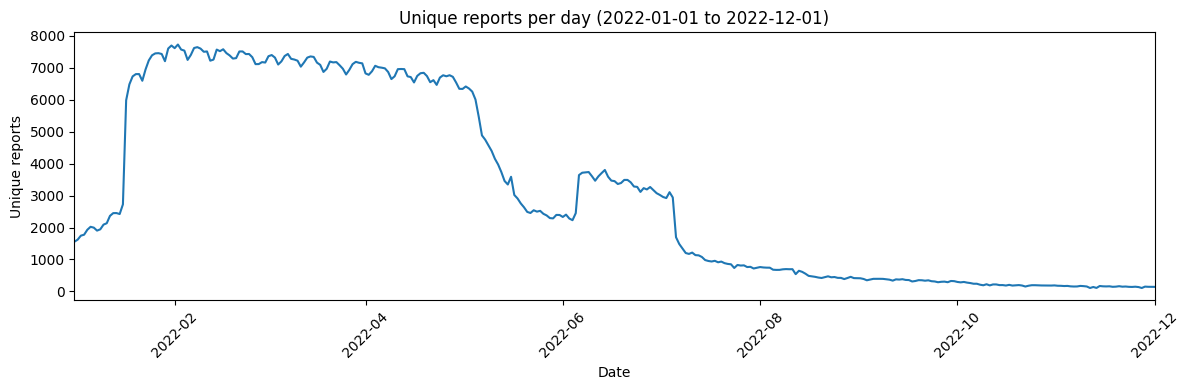

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df["date"] = df["report_created_at"].dt.normalize()
reports_per_day = df.groupby("date")["report_id"].nunique().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(reports_per_day.index, reports_per_day.values)
ax.set_xlabel("Date")
ax.set_ylabel("Unique reports")
ax.set_title("Unique reports per day (2022-01-01 to 2022-12-01)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_xlim(reports_per_day.index.min(), reports_per_day.index.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Individual microdataset

**Method:** A microdataset of individual reports is built by (1) keeping only rows where `report_symptoms` indicates at least one symptom (i.e. dropping null, empty string, and the literal `"[]"`), and (2) restricting to `report_state == "Federal District"`. The result is limited to the columns: `user_id`, `report_id`, `report_created_at`, `report_city`, `report_latitude`, `report_longitude`, and `report_symptoms`. This dataset is the basis for symptom-based time series at the individual level.

In [5]:
_report_sym = df["report_symptoms"].astype(str)
mask_symptoms = df["report_symptoms"].notna() & (_report_sym.str.strip() != "") & (_report_sym.str.strip() != "[]") & (_report_sym.str.strip() != "nan")
mask_state = df["report_state"] == "Federal District"

dataset_microdados_individuais = df.loc[mask_symptoms & mask_state, [
    "user_id", "report_id", "report_created_at", "report_city",
    "report_latitude", "report_longitude", "report_symptoms"
]].copy()

dataset_microdados_individuais.head()

,user_id,report_id,report_created_at,report_city,report_latitude,report_longitude,report_symptoms
155,7755,4395549,2022-01-01,Vicente Pires,-15.799885,-48.036485,---\n- Diarreia\n
343,4013,4396737,2022-01-01,Ceilândia,-15.791876,-48.133558,---\n- Cansaco\n- CongestãoNasal\n- DorCabeca\...
698,27091,4396438,2022-01-01,Santa Maria,-16.029414,-47.992383,---\n- Cansaco\n- CongestãoNasal\n- DorCabeca\...
921,29532,4395414,2022-01-01,Brasília,-15.765788,-47.891147,---\n- Calafrios\n- Cansaco\n- CongestãoNasal\...
1228,27990,4395168,2022-01-01,Ceilândia,-15.823146,-48.105736,---\n- CongestãoNasal\n- DordeGarganta\n- Pele...


## 3. Symptom dummy dataset

**Method:** All distinct symptoms are first extracted from the `report_symptoms` field (YAML-like format with `---` and `- SymptomName` lines). The list of symptom names is deduplicated and sorted alphabetically. Then, for each report, a dummy column is created for each symptom, with value 1 if that symptom appears in the report and 0 otherwise. The final dataset contains `user_id`, `report_id`, `report_created_at`, `report_city`, `report_latitude`, `report_longitude`, plus one column per symptom (0/1).

In [6]:
def parse_symptoms(s: str):
    """Extract list of symptom names from report_symptoms string (e.g. '---\\n- A\\n- B\\n')."""
    if pd.isna(s) or not str(s).strip() or str(s).strip() == "[]":
        return []
    out = []
    for line in str(s).splitlines():
        line = line.strip()
        if line.startswith("- "):
            out.append(line[2:].strip())
    return out

In [7]:
symptom_lists = dataset_microdados_individuais["report_symptoms"].map(parse_symptoms)
# Use full vocabulary (all_symptoms_full from section 1) so we keep all symptom columns (e.g. 42), not only those in the analysis period
all_symptoms = all_symptoms_full

base = dataset_microdados_individuais[["user_id", "report_id", "report_created_at", "report_city", "report_latitude", "report_longitude"]].copy()
for sym in all_symptoms:
    base[sym] = symptom_lists.apply(lambda lst: 1 if sym in lst else 0)

dataset_sintomas_dummy = base
dataset_sintomas_dummy.head()

,user_id,report_id,report_created_at,report_city,report_latitude,report_longitude,Bolhasna Pele,Calafrios,Cansaco,Coceira,...,Olhosvermelhoselacrimejantes,PeleEOlhosAmarelados,Sangramento,Sangueoumuconasfezes,Secreçãoesbranquiçadaouamarelada,Sensaçãodeareianosolhos,Sensibilidadeàluz,Tosse,Visãoembaçada,paladareolfato
155,7755,4395549,2022-01-01,Vicente Pires,-15.799885,-48.036485,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
343,4013,4396737,2022-01-01,Ceilândia,-15.791876,-48.133558,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
698,27091,4396438,2022-01-01,Santa Maria,-16.029414,-47.992383,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
921,29532,4395414,2022-01-01,Brasília,-15.765788,-47.891147,0,1,1,0,...,0,0,0,0,0,0,0,1,0,0
1228,27990,4395168,2022-01-01,Ceilândia,-15.823146,-48.105736,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


## 4. Modeling

Several clustering algorithms are tested on the symptom dummy matrix to find which best groups co-occurring symptoms. Each method is evaluated with its specific metrics; then symptom groups, a time-series dataset by group, and a line plot by cluster are produced for comparison.

### 4.0 Data for clustering

Only the symptom columns (0/1) are used as features. Identifiers and dates are kept for later aggregation.

In [8]:
base_cols = ["user_id", "report_id", "report_created_at", "report_city", "report_latitude", "report_longitude"]
symptom_cols = [c for c in dataset_sintomas_dummy.columns if c not in base_cols]
X_symptoms = dataset_sintomas_dummy[symptom_cols].astype(int)
dates_series = dataset_sintomas_dummy["report_created_at"]
print("Symptom columns:", len(symptom_cols))
X_symptoms.shape

Symptom columns: 42


(9052, 42)

### 4.1 K-Modes

**Algorithm:** K-Modes clusters categorical (or binary) data by minimizing the sum of matching dissimilarities: each observation is assigned to the cluster whose mode (most frequent category per feature) is closest in terms of the number of mismatches (Hamming distance).

**Metrics:**  
- **Cost:** Sum of matching dissimilarities between each point and its cluster centroid; reported by the fitted model.  
- **Silhouette Score:** Computed with Hamming distance (same as K-Modes) to measure how well separated the clusters are; higher is better.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes

def get_symptom_groups(labels, X, symptom_cols, threshold=0.3):
    """For each cluster, return symptom names that appear in at least `threshold` fraction of rows."""
    unique_labels = sorted(set(labels) - {-1}) if -1 in set(labels) else sorted(set(labels))
    groups = {}
    for k in unique_labels:
        if k == -1:
            continue
        mask = np.array(labels) == k
        if mask.sum() == 0:
            groups[k] = []
            continue
        means = X.iloc[np.where(mask)[0]][symptom_cols].mean()
        groups[k] = means[means >= threshold].index.tolist()
    return groups

def build_groups_table(labels, X, symptom_cols, threshold=0.3):
    """DataFrame with columns: cluster, sintomas_agrupados."""
    groups = get_symptom_groups(labels, X, symptom_cols, threshold)
    rows = []
    for k in sorted(groups.keys()):
        if k == -1:
            continue
        syms = groups[k] or ["(none)"]
        rows.append({"cluster": f"cluster {int(k)+1}", "sintomas_agrupados": " + ".join(syms)})
    return pd.DataFrame(rows)

def build_dataset_grupos_data(dataset_sintomas_dummy, labels, groups_df, date_col="report_created_at"):
    """Build dataset with report_created_at (YYYY/MM/DD), sintomas_agrupados, quantidade de casos. Labels are aligned by position (row i -> labels[i])."""
    cluster_to_sintomas = groups_df.set_index("cluster")["sintomas_agrupados"].to_dict()
    labels_arr = np.atleast_1d(np.asarray(labels))
    valid_labs = [i for i in sorted(set(labels_arr)) if i >= 0]
    label_to_cluster = {i: f"cluster {int(i)+1}" for i in valid_labs}
    if -1 in set(labels_arr):
        label_to_cluster[-1] = "noise"
    df = dataset_sintomas_dummy[[date_col]].copy()
    df["cluster"] = np.asarray(labels_arr).astype(int)  # keep as int for mapping
    df["cluster"] = df["cluster"].map(label_to_cluster)
    df["sintomas_agrupados"] = df["cluster"].map(cluster_to_sintomas)
    df = df[df["sintomas_agrupados"].notna()]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce").dt.normalize().dt.strftime("%Y/%m/%d")
    out = df.groupby([date_col, "sintomas_agrupados"], dropna=False).size().reset_index(name="quantidade de casos")
    return out

# Analysis period for temporal plots (same as section 1: Jan 2022 through Dec 2022)
ANALYSIS_START = pd.Timestamp("2022-01-01")
ANALYSIS_END = pd.Timestamp("2022-12-01")

def plot_clusters_over_time(dataset_grupos_data, groups_df):
    """Line plot: x=date, y=count, one line per cluster. Daily aggregation; x-axis fixed to analysis period (2022-01-01 to 2022-12-01)."""
    import matplotlib.dates as mdates
    if dataset_grupos_data.empty:
        print("No data to plot (empty dataset_grupos_data).")
        return
    key = groups_df.set_index("sintomas_agrupados")["cluster"]
    df = dataset_grupos_data.copy()
    df["cluster"] = df["sintomas_agrupados"].map(key)
    pivot = df.pivot_table(index="report_created_at", columns="cluster", values="quantidade de casos", aggfunc="sum", fill_value=0)
    pivot.index = pd.to_datetime(pivot.index, format="%Y/%m/%d", errors="coerce")
    pivot = pivot.dropna(how="all", axis=0)
    pivot = pivot.sort_index()
    if pivot.empty:
        print("No data to plot after pivot.")
        return
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], label=col)
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of cases")
    ax.set_title("Symptom clusters over time (daily counts, 2022-01-01 to 2022-12-01)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.set_xlim(ANALYSIS_START, ANALYSIS_END)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
class KModeClusterer:
    """Fit K-Modes on symptom matrix and expose cost and labels."""
    def __init__(self, n_clusters=5, init="Huang", n_init=5, random_state=42):
        self.n_clusters = n_clusters
        self.model = KModes(n_clusters=n_clusters, init=init, n_init=n_init, random_state=random_state)
        self.labels_ = None
        self.cost_ = None

    def fit(self, X):
        self.model.fit(X)
        self.labels_ = self.model.labels_
        self.cost_ = self.model.cost_
        return self

In [11]:
n_clusters_km = 5
km = KModeClusterer(n_clusters=n_clusters_km)
km.fit(X_symptoms)
cost_km = km.cost_
silhouette_km = silhouette_score(X_symptoms, km.labels_, metric="hamming")
print("4.1 K-Modes")
print("  Cost (sum of matching dissimilarities):", cost_km)
print("  Silhouette Score (Hamming):", round(silhouette_km, 4))
groups_km = build_groups_table(km.labels_, X_symptoms, symptom_cols)
groups_km

4.1 K-Modes
  Cost (sum of matching dissimilarities): 19107.0
  Silhouette Score (Hamming): 0.1549


,cluster,sintomas_agrupados
0,cluster 1,Cansaco + CongestãoNasal + DorCabeca + DordeGa...
1,cluster 2,CongestãoNasal + DordeGarganta
2,cluster 3,Cansaco + DorCabeca + Mal-estar
3,cluster 4,Cansaco + DorCabeca
4,cluster 5,Tosse


In [12]:
dataset_grupos_data_km = build_dataset_grupos_data(dataset_sintomas_dummy, km.labels_, groups_km)
dataset_grupos_data_km.head(10)

,report_created_at,sintomas_agrupados,quantidade de casos
0,2022/01/01,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,2
1,2022/01/01,Cansaco + DorCabeca + Mal-estar,1
2,2022/01/01,CongestãoNasal + DordeGarganta,2
3,2022/01/01,Tosse,1
4,2022/01/02,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,6
5,2022/01/02,Cansaco + DorCabeca,3
6,2022/01/02,Cansaco + DorCabeca + Mal-estar,2
7,2022/01/02,CongestãoNasal + DordeGarganta,3
8,2022/01/02,Tosse,5
9,2022/01/03,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,18


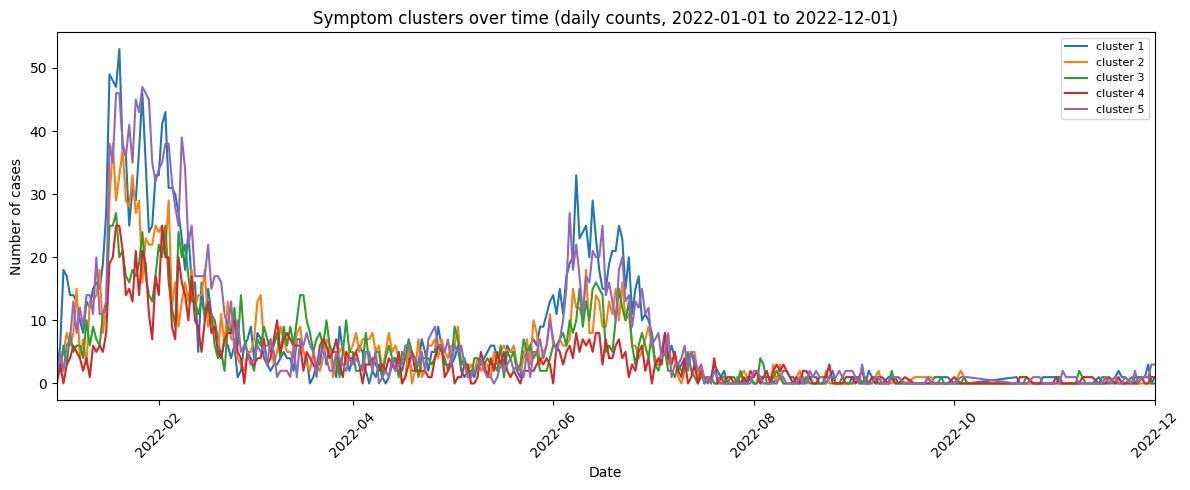

In [13]:
plot_clusters_over_time(dataset_grupos_data_km, groups_km)

### 4.2 Latent Class Analysis (LCA) / Bernoulli Mixture Models

**Algorithm:** Latent class models assume that each observation belongs to one of K latent classes; within each class, features follow a class-specific distribution. For binary symptoms, a Bernoulli mixture (each class has its own probability per symptom) is the natural model. Here we use a Gaussian mixture on the 0/1 symptom matrix as a continuous proxy; the mixture still yields soft or hard class assignments and information criteria.

**Metrics:**  
- **BIC (Bayesian Information Criterion):** Penalized likelihood; lower BIC suggests a better trade-off between fit and complexity.  
- **AIC (Akaike Information Criterion):** Similar role; lower AIC is better.

In [14]:
# Shared helpers already defined in 4.1 (get_symptom_groups, build_groups_table, build_dataset_grupos_data, plot_clusters_over_time)
from sklearn.mixture import GaussianMixture

In [15]:
class GaussianMixtureClusterer:
    """Fit Gaussian Mixture on symptom matrix (proxy for LCA); exposes AIC, BIC, and hard labels."""
    def __init__(self, n_components=5, random_state=42, **kwargs):
        self.n_components = n_components
        self.model = GaussianMixture(n_components=n_components, random_state=random_state, **kwargs)
        self.labels_ = None
        self.aic_ = None
        self.bic_ = None

    def fit(self, X):
        self.model.fit(X)
        self.labels_ = self.model.predict(X)
        self.aic_ = self.model.aic(X)
        self.bic_ = self.model.bic(X)
        return self

In [16]:
n_components_lca = 5
gmm = GaussianMixtureClusterer(n_components=n_components_lca)
gmm.fit(X_symptoms)
print("4.2 LCA / Bernoulli Mixture (Gaussian Mixture proxy)")
print("  BIC:", round(gmm.bic_, 2))
print("  AIC:", round(gmm.aic_, 2))
groups_lca = build_groups_table(gmm.labels_, X_symptoms, symptom_cols)
groups_lca

4.2 LCA / Bernoulli Mixture (Gaussian Mixture proxy)
  BIC: -3185405.45
  AIC: -3219032.15


,cluster,sintomas_agrupados
0,cluster 1,Cansaco + CongestãoNasal + DorCabeca + DordeGa...
1,cluster 2,Cansaco + CongestãoNasal + DificuldadeParaResp...
2,cluster 3,Cansaco + CongestãoNasal + DordeGarganta + Tosse
3,cluster 4,Calafrios + Cansaco + CongestãoNasal + DorCabe...
4,cluster 5,Calafrios + Cansaco + CongestãoNasal + DorCabe...


In [17]:
dataset_grupos_data_lca = build_dataset_grupos_data(dataset_sintomas_dummy, gmm.labels_, groups_lca)
dataset_grupos_data_lca.head(10)

,report_created_at,sintomas_agrupados,quantidade de casos
0,2022/01/01,Calafrios + Cansaco + CongestãoNasal + DorCabe...,1
1,2022/01/01,Calafrios + Cansaco + CongestãoNasal + DorCabe...,1
2,2022/01/01,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,2
3,2022/01/01,Cansaco + CongestãoNasal + DordeGarganta + Tosse,2
4,2022/01/02,Calafrios + Cansaco + CongestãoNasal + DorCabe...,4
5,2022/01/02,Cansaco + CongestãoNasal + DificuldadeParaResp...,1
6,2022/01/02,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,8
7,2022/01/02,Cansaco + CongestãoNasal + DordeGarganta + Tosse,6
8,2022/01/03,Calafrios + Cansaco + CongestãoNasal + DorCabe...,3
9,2022/01/03,Calafrios + Cansaco + CongestãoNasal + DorCabe...,9


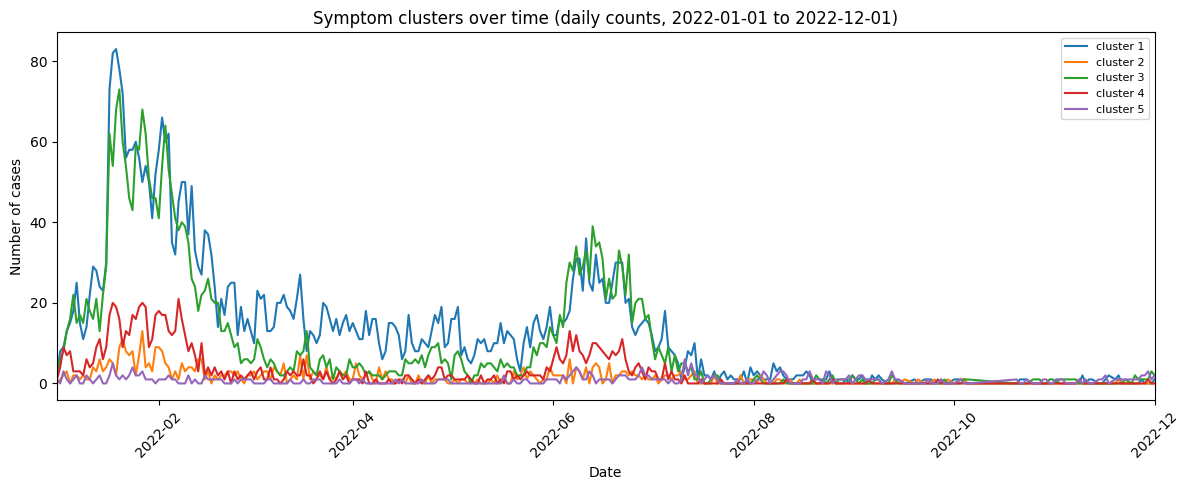

In [18]:
plot_clusters_over_time(dataset_grupos_data_lca, groups_lca)

### 4.3 Hierarchical (Agglomerative) Clustering with Jaccard Distance

**Algorithm:** Agglomerative clustering merges the two closest clusters repeatedly. Pairwise distances between observations are computed with the Jaccard distance (1 − Jaccard similarity) on the binary symptom vectors, so that similarity is based on shared symptoms. The linkage (e.g. average) then operates on this distance matrix.

**Metrics:**  
- **Cophenetic correlation coefficient:** Correlation between the original pairwise distances and the distances in the dendrogram (cophenetic distances); higher values indicate that the dendrogram represents the distance structure well.  
- **Davies–Bouldin index:** Ratio of within-cluster scatter to between-cluster separation; lower is better.

In [19]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from sklearn.metrics import davies_bouldin_score

def jaccard_linkage_labels(X, n_clusters=5, method="average"):
    """Compute condensed Jaccard distance, linkage, and flat cluster labels."""
    cond = pdist(X.values, metric="jaccard")
    Z = linkage(cond, method=method)
    labels = fcluster(Z, n_clusters, criterion="maxclust") - 1  # 0-based
    return Z, cond, labels

In [20]:
class HierarchicalJaccardClusterer:
    """Agglomerative clustering with Jaccard distance; exposes cophenetic correlation and Davies-Bouldin."""
    def __init__(self, n_clusters=5, method="average"):
        self.n_clusters = n_clusters
        self.method = method
        self.labels_ = None
        self.Z_ = None
        self.cophenetic_corr_ = None
        self.davies_bouldin_ = None

    def fit(self, X):
        self.Z_, cond, self.labels_ = jaccard_linkage_labels(X, self.n_clusters, self.method)
        coph, self.cophenetic_corr_ = cophenet(self.Z_, cond)
        self.davies_bouldin_ = davies_bouldin_score(X, self.labels_)
        return self

In [21]:
n_clusters_h = 5
hier = HierarchicalJaccardClusterer(n_clusters=n_clusters_h, method="average")
hier.fit(X_symptoms)
print("4.3 Hierarchical (Jaccard)")
print("  Cophenetic correlation coefficient:", round(float(np.asarray(hier.cophenetic_corr_).flat[0]), 4))
print("  Davies-Bouldin index:", round(float(np.asarray(hier.davies_bouldin_).flat[0]), 4))
groups_hier = build_groups_table(hier.labels_, X_symptoms, symptom_cols)
groups_hier

4.3 Hierarchical (Jaccard)
  Cophenetic correlation coefficient: 0.9196
  Davies-Bouldin index: 1.7151


,cluster,sintomas_agrupados
0,cluster 1,Sangramento + paladareolfato
1,cluster 2,Bolhasna Pele + ManchasRoxasPeloCorpo
2,cluster 3,Dornocorpo + Fadiga
3,cluster 4,Cansaco + Coceira
4,cluster 5,Cansaco + CongestãoNasal + DorCabeca + DordeGa...


In [22]:
dataset_grupos_data_hier = build_dataset_grupos_data(dataset_sintomas_dummy, hier.labels_, groups_hier)
dataset_grupos_data_hier.head(10)

,report_created_at,sintomas_agrupados,quantidade de casos
0,2022/01/01,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,6
1,2022/01/02,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,19
2,2022/01/03,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,31
3,2022/01/04,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,37
4,2022/01/05,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,39
5,2022/01/06,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,46
6,2022/01/07,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,47
7,2022/01/08,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,36
8,2022/01/09,Cansaco + Coceira,1
9,2022/01/09,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,29


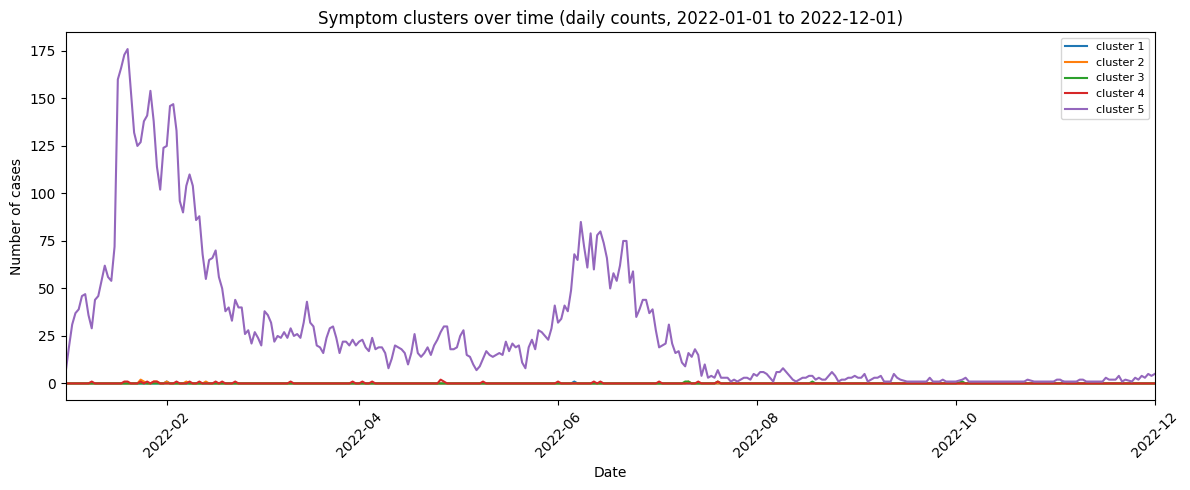

In [23]:
plot_clusters_over_time(dataset_grupos_data_hier, groups_hier)

### 4.4 Non-negative Matrix Factorization (NMF)

**Algorithm:** NMF approximates the data matrix X as the product of two non-negative matrices W (samples × components) and H (components × features). Each sample is assigned to the component for which the corresponding weight is largest, yielding a clustering. It is well suited to non-negative (e.g. count or binary) data such as symptom indicators.

**Metrics:**  
- **Reconstruction error (Frobenius norm):** ‖X − WH‖_F; lower means a better approximation.  
- **Residuals:** Same reconstruction residuals (element-wise X − WH), often summarized as norm or mean absolute error; lower is better.

In [24]:
from sklearn.decomposition import NMF

def nmf_cluster_metrics(model, X):
    """Reconstruction error (Frobenius) and mean absolute residuals."""
    W = model.transform(X)
    H = model.components_
    R = X - W @ H
    frob = np.sqrt(np.sum(R ** 2))
    residuals = np.abs(R).mean()
    return frob, residuals

In [25]:
class NMFClusterer:
    """NMF on symptom matrix; assign each sample to component with largest weight; expose Frobenius and residuals."""
    def __init__(self, n_components=5, random_state=42, **kwargs):
        self.n_components = n_components
        self.model = NMF(n_components=n_components, random_state=random_state, **kwargs)
        self.labels_ = None
        self.frobenius_ = None
        self.residuals_ = None

    def fit(self, X):
        self.model.fit(X)
        W = self.model.transform(X)
        self.labels_ = np.argmax(W, axis=1)
        self.frobenius_, self.residuals_ = nmf_cluster_metrics(self.model, X)
        return self

In [26]:
n_components_nmf = 5
nmf = NMFClusterer(n_components=n_components_nmf)
nmf.fit(X_symptoms)
print("4.4 NMF")
print("  Reconstruction error (Frobenius norm):", round(nmf.frobenius_, 4))
print("  Residuals (mean absolute):", round(nmf.residuals_, 4))
groups_nmf = build_groups_table(nmf.labels_, X_symptoms, symptom_cols)
groups_nmf

4.4 NMF
  Reconstruction error (Frobenius norm): Bolhasna Pele                            8.0875
Calafrios                               26.0217
Cansaco                                 26.1532
Coceira                                 14.6701
Coloraçãoazuladanoslábiosourosto         0.0000
CongestãoNasal                           2.5055
Conjuntivite                             5.4574
Coriza                                   0.0000
Diarreia                                23.6565
DificuldadeParaRespirar                 24.0568
Diminuiçãodaurina                        0.0000
Diminuiçãodoapetite                      0.0000
DorCabeca                                8.4961
DorDeEstômago                           20.8953
DorNasArticulações                      25.3218
DorNosMúsculos                          26.7474
DorNosOlhos                             26.7406
Doratrásdosolhos                         5.6309
DordeGarganta                            1.5560
DornoPeito                             

/Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,cluster,sintomas_agrupados
0,cluster 1,Cansaco + Mal-estar
1,cluster 2,Tosse
2,cluster 3,CongestãoNasal + DordeGarganta + Tosse
3,cluster 4,Cansaco + CongestãoNasal + Tosse
4,cluster 5,Cansaco + CongestãoNasal + DorCabeca + DordeGa...


In [27]:
dataset_grupos_data_nmf = build_dataset_grupos_data(dataset_sintomas_dummy, nmf.labels_, groups_nmf)
dataset_grupos_data_nmf.head(10)

,report_created_at,sintomas_agrupados,quantidade de casos
0,2022/01/01,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,3
1,2022/01/01,Cansaco + Mal-estar,1
2,2022/01/01,CongestãoNasal + DordeGarganta + Tosse,2
3,2022/01/02,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,6
4,2022/01/02,Cansaco + CongestãoNasal + Tosse,3
5,2022/01/02,Cansaco + Mal-estar,4
6,2022/01/02,CongestãoNasal + DordeGarganta + Tosse,3
7,2022/01/02,Tosse,3
8,2022/01/03,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,18
9,2022/01/03,Cansaco + CongestãoNasal + Tosse,6


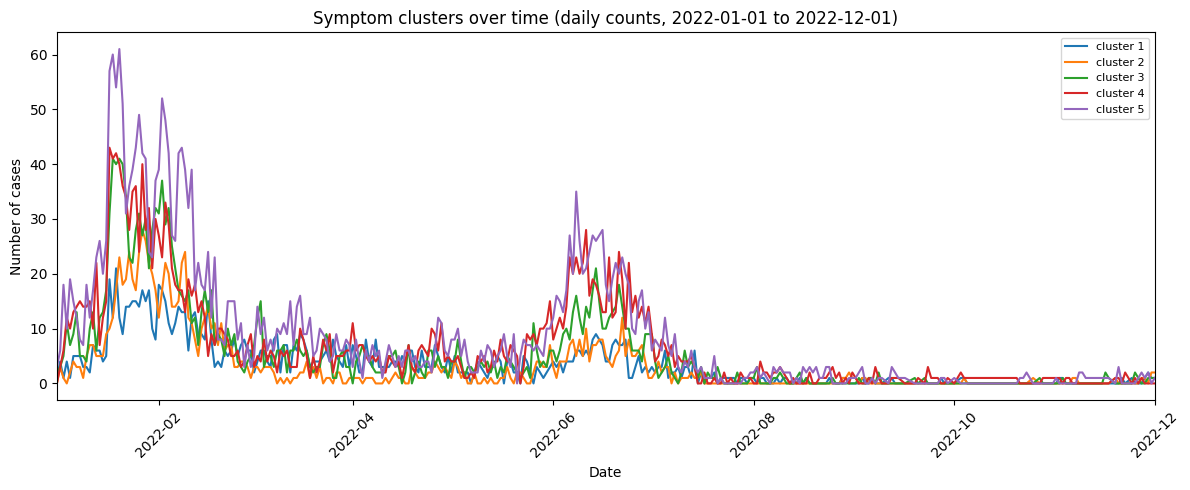

In [28]:
plot_clusters_over_time(dataset_grupos_data_nmf, groups_nmf)

### 4.5 DBSCAN (Jaccard distance)

**Algorithm:** DBSCAN groups points that lie in dense regions (neighbourhood of radius ε with at least min_samples points). Points in sparse regions are labeled as noise (−1). Using Jaccard distance on the binary symptom vectors ensures that similarity is defined by shared symptoms.

**Metrics:**  
- **Silhouette Score:** Using the same Jaccard distance as the model; computed only on non-noise points. Higher is better.  
- **Noise ratio:** Proportion of points classified as −1 (outliers); lower means more points assigned to clusters.

In [29]:
from sklearn.cluster import DBSCAN

def dbscan_jaccard_metrics(X, labels):
    """Silhouette (Jaccard, non-noise only) and noise ratio."""
    cond = pdist(X.values, metric="jaccard")
    dist_sq = squareform(cond)
    mask = np.array(labels) != -1
    n_clusters = len(set(labels) - {-1})
    if mask.sum() > 0 and n_clusters >= 2:
        sub = dist_sq[mask][:, mask]
        sil = silhouette_score(sub, labels[mask], metric="precomputed")
    else:
        sil = np.nan
    noise_ratio = (np.array(labels) == -1).mean()
    return sil, noise_ratio

In [30]:
class DBSCANJaccardClusterer:
    """DBSCAN with precomputed Jaccard distance; exposes Silhouette and noise ratio."""
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        self.silhouette_ = None
        self.noise_ratio_ = None

    def fit(self, X):
        cond = pdist(X.values, metric="jaccard")
        dist_sq = squareform(cond)
        self.model = DBSCAN(eps=self.eps, min_samples=self.min_samples, metric="precomputed")
        self.labels_ = self.model.fit_predict(dist_sq)
        self.silhouette_, self.noise_ratio_ = dbscan_jaccard_metrics(X, self.labels_)
        return self

In [31]:
db = DBSCANJaccardClusterer(eps=0.5, min_samples=5)
db.fit(X_symptoms)
print("4.5 DBSCAN (Jaccard)")
print("  Silhouette Score (Jaccard, non-noise):", round(db.silhouette_, 4) if not np.isnan(db.silhouette_) else "N/A (need ≥2 clusters)")
print("  Noise ratio (% labeled -1):", round(db.noise_ratio_ * 100, 2), "%")
groups_db = build_groups_table(db.labels_, X_symptoms, symptom_cols)
groups_db

4.5 DBSCAN (Jaccard)
  Silhouette Score (Jaccard, non-noise): N/A (need ≥2 clusters)
  Noise ratio (% labeled -1): 0.0 %


,cluster,sintomas_agrupados
0,cluster 1,Cansaco + CongestãoNasal + DorCabeca + DordeGa...


In [32]:
dataset_grupos_data_db = build_dataset_grupos_data(dataset_sintomas_dummy, db.labels_, groups_db)
dataset_grupos_data_db.head(10)

,report_created_at,sintomas_agrupados,quantidade de casos
0,2022/01/01,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,6
1,2022/01/02,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,19
2,2022/01/03,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,31
3,2022/01/04,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,37
4,2022/01/05,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,39
5,2022/01/06,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,46
6,2022/01/07,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,47
7,2022/01/08,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,36
8,2022/01/09,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,30
9,2022/01/10,Cansaco + CongestãoNasal + DorCabeca + DordeGa...,44


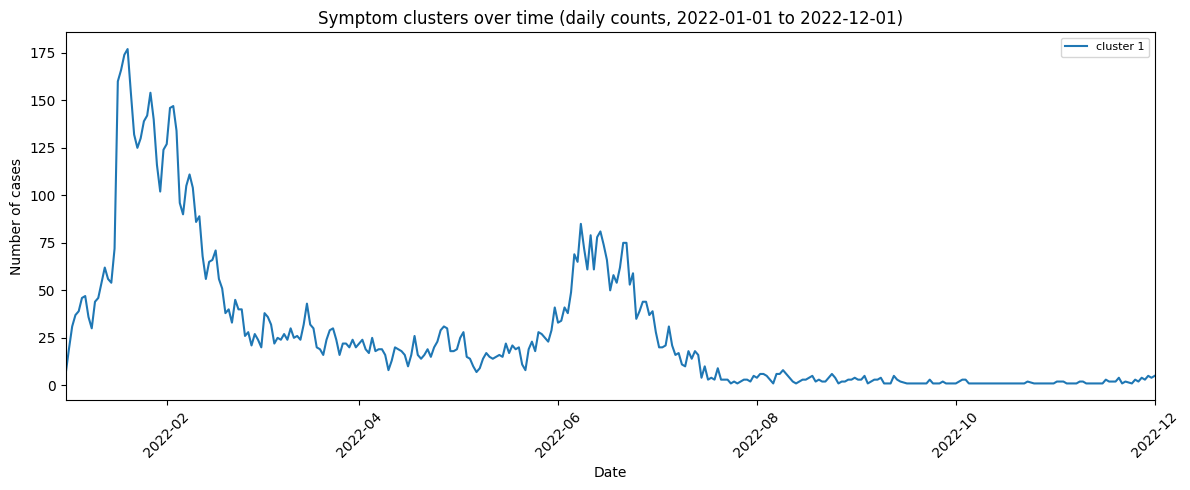

In [33]:
plot_clusters_over_time(dataset_grupos_data_db, groups_db)

## 5. Chosen modeling

We use a **graph-based approach with Jaccard similarity** to group symptom occurrences into "families" (likely diseases/syndromes). The unit of analysis is **unique symptom combinations** (co-occurrence patterns), not individual users.

**Methodology:**

1. **Preprocessing**
   - **Metadata columns** (excluded from symptoms): `user_id`, `report_id`, `report_created_at`, `report_city`, `report_latitude`, `report_longitude`. All other columns are dummy (0/1) symptom variables.
   - We add a temporary column `sintomas_lista`: for each row, a string (or list) of symptom names where the value is 1 (e.g. `"febre, dor_cabeca"`).
   - We build an auxiliary DataFrame **`df_combinacoes_unicas`** with each **unique** symptom combination present in the data and assign a **combination ID**. Rows with no symptoms (all zeros) are dropped.

2. **Graph construction and clustering**
   - **Jaccard similarity** is computed between every pair of unique symptom combinations (on the binary symptom vectors). Jaccard = |A ∩ B| / |A ∪ B|; we use it to measure how much two symptom sets overlap.
   - A **graph** (NetworkX) is built where:
     - **Nodes** = unique symptom combinations (one node per combination ID).
     - **Edges** = only between pairs whose Jaccard similarity is **above a threshold** (default 0.5). Edge **weight** = Jaccard similarity.
   - **Community detection**: we use **Louvain** (package `python-louvain` / `community`) or, if unavailable, **`greedy_modularity_communities`** from NetworkX to find communities. Each community is treated as one **cluster** (one probable syndrome/family).

3. **Outputs**
   - **Output 1 — `sintomas_agrupados`**: summary DataFrame with columns `cluster` (cluster ID) and `sintomas` (list or string of symptom combinations in that cluster).
   - **Output 2 — `dataset_sintomas_grupos`**: original `dataset_sintomas_dummy` plus:
     - `sintomas_agrupados`: string of the symptom combination for that row.
     - `cluster`: cluster ID from the graph clustering (merge by combination). Rows with no symptoms get cluster **-1** or NaN.
   - Original columns (e.g. `user_id`, `report_created_at`) are kept.

Libraries: **pandas**, **networkx**, **itertools**, **sklearn.metrics**; vectorized operations are used where possible.

In [34]:
# Metadata columns (all other columns are symptom dummies)
METADATA_COLS = ["user_id", "report_id", "report_created_at", "report_city", "report_latitude", "report_longitude"]

def get_symptom_columns(df, metadata_cols=None):
    """Return list of symptom columns (all columns not in metadata)."""
    metadata_cols = metadata_cols or METADATA_COLS
    return [c for c in df.columns if c not in metadata_cols]

def _dedupe_symptom_string(s, sep=", "):
    """Remove sintomas repetidos na string, preservando a ordem da primeira ocorrência."""
    if pd.isna(s) or not str(s).strip():
        return ""
    parts = [x.strip() for x in str(s).split(sep) if x.strip()]
    seen = set()
    out = [x for x in parts if x not in seen and not seen.add(x)]
    return sep.join(out)

def add_sintomas_lista(df, symptom_cols, sep=", "):
    """Add column sintomas_lista: string of symptom names where value is 1 (deduplicated)."""
    def row_to_symptoms(row):
        present = [s for s in symptom_cols if row[s] == 1]
        return sep.join(present) if present else ""
    df = df.copy()
    df["sintomas_lista"] = df[symptom_cols].apply(lambda row: row_to_symptoms(row), axis=1)
    df["sintomas_lista"] = df["sintomas_lista"].apply(_dedupe_symptom_string)
    return df

def build_unique_combinations_df(df, sintomas_lista_col="sintomas_lista"):
    """DataFrame of unique symptom combinations with combination_id. Drops rows with no symptoms. Deduplicates symptoms within each combination."""
    comb = df[[sintomas_lista_col]].copy()
    comb[sintomas_lista_col] = comb[sintomas_lista_col].apply(_dedupe_symptom_string)
    comb = comb.drop_duplicates()
    comb = comb[comb[sintomas_lista_col].str.len() > 0].reset_index(drop=True)
    comb["combination_id"] = np.arange(len(comb))
    return comb

def jaccard_similarity_matrix(df_unique, df_full, symptom_cols, sintomas_lista_col="sintomas_lista"):
    """Compute Jaccard similarity between rows of df_unique (by matching sintomas_lista in df_full)."""
    from sklearn.metrics import pairwise_distances
    # Merge to get one row per unique combination with binary symptom vector
    merged = df_full.drop_duplicates(subset=[sintomas_lista_col]).merge(
        df_unique[[sintomas_lista_col, "combination_id"]], on=sintomas_lista_col, how="right"
    )
    merged = merged.sort_values("combination_id").reset_index(drop=True)
    X = merged[symptom_cols].astype(int).values
    # pairwise_distances with metric='jaccard' gives Jaccard distance; similarity = 1 - distance
    dist = pairwise_distances(X, metric="jaccard")
    sim = 1.0 - dist
    np.fill_diagonal(sim, 1.0)
    return sim, merged

def build_similarity_graph(sim_matrix, combination_ids, threshold=0.3):
    """Build NetworkX graph: nodes = combination_id, edges if similarity > threshold, weight = similarity."""
    import networkx as nx
    G = nx.Graph()
    n = sim_matrix.shape[0]
    for i in range(n):
        G.add_node(int(combination_ids.iloc[i]))
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] > threshold:
                G.add_edge(int(combination_ids.iloc[i]), int(combination_ids.iloc[j]), weight=float(sim_matrix[i, j]))
    return G

def detect_communities_louvain_or_greedy(G):
    """Return partition: dict node -> community id. Prefer Louvain, else greedy_modularity."""
    try:
        import community as community_louvain
        partition = community_louvain.best_partition(G)
        return partition
    except ImportError:
        from networkx.algorithms.community import greedy_modularity_communities
        communities = list(greedy_modularity_communities(G))
        partition = {}
        for cid, comm in enumerate(communities):
            for node in comm:
                partition[node] = cid
        return partition

def build_sintomas_agrupados_df(df_unique, sintomas_lista_col="sintomas_lista"):
    """Output 1: DataFrame with columns cluster and sintomas (list of combinations per cluster). df_unique must have 'cluster' column."""
    agg = df_unique.groupby("cluster", as_index=False)[sintomas_lista_col].agg(sintomas=lambda x: list(x))
    return agg

def _cluster_to_aggregated_symptoms(df_unique, sintomas_lista_col="sintomas_lista"):
    """Map cluster_id -> string of all unique symptoms in that cluster (from df_unique combinations)."""
    out = {}
    for c, g in df_unique.groupby("cluster"):
        all_syms = set()
        for s in g[sintomas_lista_col]:
            for sym in str(s).split(","):
                all_syms.add(sym.strip())
        out[c] = ", ".join(sorted(all_syms)) if all_syms else ""
    return out

def build_dataset_sintomas_grupos(dataset_sintomas_dummy, df_unique, sintomas_lista_col="sintomas_lista"):
    """Output 2: Original dataset + sintomas_lista (row symptoms) + sintomas_agrupados (all symptoms of the cluster) + cluster. No symptoms -> cluster -1."""
    df = dataset_sintomas_dummy.copy()
    if sintomas_lista_col not in df.columns:
        raise ValueError("dataset must have column sintomas_lista; run add_sintomas_lista first.")
    sintomas_to_cluster = df_unique.set_index(sintomas_lista_col)["cluster"].to_dict()
    df["cluster"] = df[sintomas_lista_col].map(sintomas_to_cluster).fillna(-1).astype(int)
    df.loc[df[sintomas_lista_col].str.len() == 0, "cluster"] = -1
    cluster_to_symptoms = _cluster_to_aggregated_symptoms(df_unique, sintomas_lista_col)
    df["sintomas_agrupados"] = df["cluster"].map(cluster_to_symptoms).fillna("")
    return df


# Gráfico temporal dos clusters (chamado na célula de salvamento)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_section5_clusters_over_time(dataset_sintomas_grupos, analysis_start=None, analysis_end=None):
    """Line plot: x=date, y=count, one line per cluster. Excludes cluster=-1 (no symptoms)."""
    if analysis_start is None:
        analysis_start = pd.Timestamp("2022-01-01")
    if analysis_end is None:
        analysis_end = pd.Timestamp("2022-12-01")
    df = dataset_sintomas_grupos.copy()
    df["date"] = pd.to_datetime(df["report_created_at"], errors="coerce").dt.normalize()
    df = df[(df["date"] >= analysis_start) & (df["date"] <= analysis_end)]
    df = df[df["cluster"] >= 0]  # exclude no-symptoms
    if df.empty:
        print("No data to plot (empty or all cluster=-1).")
        return
    counts = df.groupby([df["date"], "cluster"]).size().reset_index(name="count")
    pivot = counts.pivot_table(index="date", columns="cluster", values="count", aggfunc="sum", fill_value=0)
    pivot = pivot.sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], label=f"Cluster {int(col)}")
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of cases")
    ax.set_title("Section 5 — Graph-based clusters over time (daily counts, 2022-01-01 to 2022-12-01)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.set_xlim(analysis_start, analysis_end)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [35]:
class SymptomGraphClusterer:
    """Runs the full pipeline: preprocessing -> Jaccard graph -> community detection -> outputs."""

    def __init__(self, similarity_threshold=0.5, metadata_cols=None):
        self.similarity_threshold = similarity_threshold
        self.metadata_cols = metadata_cols or METADATA_COLS
        self.symptom_cols_ = None
        self.df_combinacoes_unicas_ = None
        self.partition_ = None
        self.sintomas_agrupados_ = None
        self.dataset_sintomas_grupos_ = None

    def fit(self, dataset_sintomas_dummy):
        symptom_cols = get_symptom_columns(dataset_sintomas_dummy, self.metadata_cols)
        self.symptom_cols_ = symptom_cols
        df = add_sintomas_lista(dataset_sintomas_dummy, symptom_cols)
        df_unique = build_unique_combinations_df(df)
        if len(df_unique) == 0:
            self.partition_ = {}
            self.df_combinacoes_unicas_ = df_unique.copy()
            self.df_combinacoes_unicas_["cluster"] = pd.Series(dtype=int)
            self.sintomas_agrupados_ = pd.DataFrame(columns=["cluster", "sintomas"])
            self.dataset_sintomas_grupos_ = df.copy()
            self.dataset_sintomas_grupos_["cluster"] = -1
            return self
        sim, _ = jaccard_similarity_matrix(df_unique, df, symptom_cols)
        G = build_similarity_graph(sim, df_unique["combination_id"], threshold=self.similarity_threshold)
        self.partition_ = detect_communities_louvain_or_greedy(G)
        df_unique = df_unique.copy()
        df_unique["cluster"] = df_unique["combination_id"].map(self.partition_)
        self.df_combinacoes_unicas_ = df_unique
        self.sintomas_agrupados_ = build_sintomas_agrupados_df(df_unique)
        self.dataset_sintomas_grupos_ = build_dataset_sintomas_grupos(df, df_unique)
        return self

In [36]:
# Run graph-based clustering on dataset_sintomas_dummy
clusterer = SymptomGraphClusterer(similarity_threshold=0.3)
clusterer.fit(dataset_sintomas_dummy)

sintomas_agrupados = clusterer.sintomas_agrupados_
dataset_sintomas_grupos = clusterer.dataset_sintomas_grupos_
df_combinacoes_unicas = clusterer.df_combinacoes_unicas_

print("Unique symptom combinations:", len(df_combinacoes_unicas))
print("Clusters (communities):", sintomas_agrupados["cluster"].nunique())
sintomas_agrupados

dataset_sintomas_grupos.head(10)

/Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/venv/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2462: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Unique symptom combinations: 2397
Clusters (communities): 4


,user_id,report_id,report_created_at,report_city,report_latitude,report_longitude,Bolhasna Pele,Calafrios,Cansaco,Coceira,...,Sangueoumuconasfezes,Secreçãoesbranquiçadaouamarelada,Sensaçãodeareianosolhos,Sensibilidadeàluz,Tosse,Visãoembaçada,paladareolfato,sintomas_lista,cluster,sintomas_agrupados
155,7755,4395549,2022-01-01,Vicente Pires,-15.799885,-48.036485,0,0,0,0,...,0,0,0,0,0,0,0,Diarreia,1,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
343,4013,4396737,2022-01-01,Ceilândia,-15.791876,-48.133558,0,0,1,0,...,0,0,0,0,1,0,0,"Cansaco, CongestãoNasal, DorCabeca, Tosse",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
698,27091,4396438,2022-01-01,Santa Maria,-16.029414,-47.992383,0,0,1,0,...,0,0,0,0,1,0,0,"Cansaco, CongestãoNasal, DorCabeca, DorNosMúsc...",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
921,29532,4395414,2022-01-01,Brasília,-15.765788,-47.891147,0,1,1,0,...,0,0,0,0,1,0,0,"Calafrios, Cansaco, CongestãoNasal, Dificuldad...",1,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1228,27990,4395168,2022-01-01,Ceilândia,-15.823146,-48.105736,0,0,0,0,...,0,0,0,0,0,0,0,"CongestãoNasal, DordeGarganta, PeleEOlhosAmare...",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1289,27264,4396307,2022-01-01,Núcleo Bandeirante,-15.870428,-47.964838,0,1,0,0,...,0,0,0,0,0,0,0,"Calafrios, CongestãoNasal, DordeGarganta",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1579,14652,4397211,2022-01-02,Paranoá,-15.775995,-47.780621,0,0,0,0,...,0,0,0,0,0,0,0,"CongestãoNasal, DificuldadeParaRespirar, DorCa...",1,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1854,32679,4398166,2022-01-02,Águas Claras,-15.829152,-48.010892,0,0,0,0,...,0,0,0,0,1,0,0,"CongestãoNasal, Mal-estar, Tosse",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1993,24702,4398428,2022-01-02,Candangolândia,-15.849573,-47.946488,0,1,1,0,...,0,0,0,0,1,0,0,"Calafrios, Cansaco, CongestãoNasal, Dificuldad...",1,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
2078,27990,4397352,2022-01-02,Ceilândia,-15.823194,-48.105725,0,0,0,0,...,0,0,0,0,1,0,0,"CongestãoNasal, DordeGarganta, Tosse",0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."


In [37]:
# Dataset: ID do cluster e sintomas dos clusters (apenas exibição, sem HTML/plot)
cluster_to_sintomas = _cluster_to_aggregated_symptoms(clusterer.df_combinacoes_unicas_, "sintomas_lista")
tab = pd.DataFrame([
    {"Cluster": cid, "Sintomas": cluster_to_sintomas.get(cid, "")}
    for cid in sorted(cluster_to_sintomas.keys())
])
tab

,Cluster,Sintomas
0,0,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
1,1,"Bolhasna Pele, Calafrios, Cansaco, Coceira, Co..."
2,2,"Calafrios, Cansaco, Coceira, CongestãoNasal, D..."
3,3,"Coceira, Diarreia, ManchasRoxasPeloCorpo"


/var/folders/x5/8fz8g47158x6v41nsnmrczsh0000gn/T/ipykernel_4969/2142376120.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _n_unicos = _df.groupby("cluster").apply(lambda g: g[["user_id", "_date"]].drop_duplicates().shape[0])


Raiz do projeto: /Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience
Base results: /Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/data/results
Salvo: /Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/data/results/clusters_outputs/clusters_outputs_sintomas_agrupados.xlsx
Salvo: /Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/data/results/clusters_outputs/clusters_outputs_dataset_sintomas_grupos.xlsx
time_series_outputs: /Users/daniellybx/Documents/Projeto ProEpi GdS /projeto_proepi_gds_datascience/data/results/time_series_outputs
Salvamento concluído.


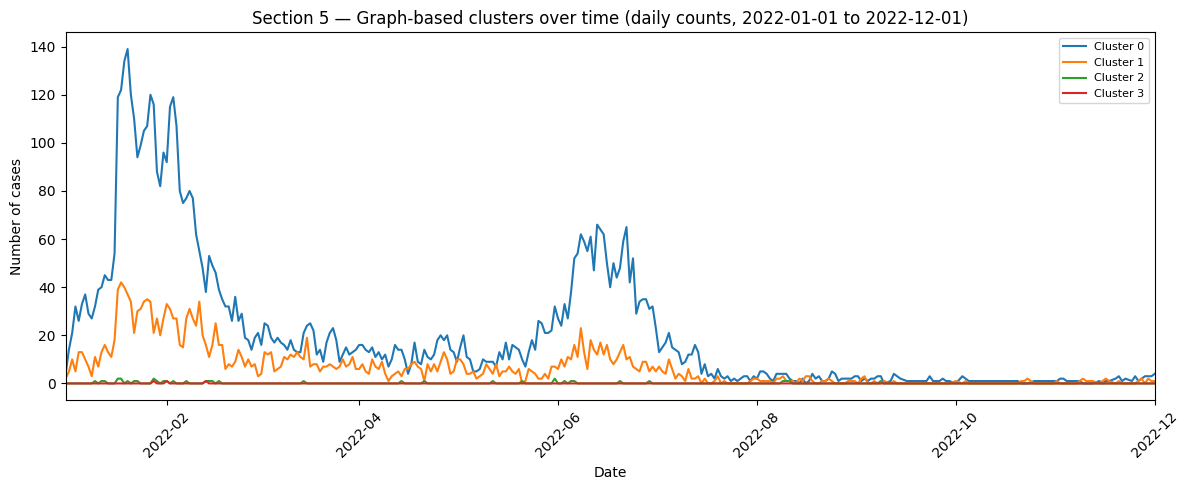

In [38]:
import os
from pathlib import Path

def _find_project_root():
    """Raiz do projeto: sobe a partir do cwd até achar pasta com 'data' e '.git' ou 'notebooks'."""
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "data").is_dir() and ((p / ".git").exists() or (p / "notebooks").is_dir()):
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd().resolve()

project_root = _find_project_root()
base = project_root / "data" / "results"
archive_dir = base / "archive"
clusters_dir = base / "clusters_outputs"
time_series_dir = base / "time_series_outputs"

# 1) Criar pastas (os.makedirs para garantir criação)
for d in (base, archive_dir, clusters_dir, time_series_dir):
    os.makedirs(str(d.resolve()), exist_ok=True)

# 2) Salvar tabelas em Excel (caminhos absolutos)
# sintomas_agrupados: exportar com sintomas ÚNICOS por cluster (não lista de combinações)
cluster_to_sintomas = _cluster_to_aggregated_symptoms(df_combinacoes_unicas, "sintomas_lista")
sintomas_agrupados_export = pd.DataFrame({
    "cluster": sorted(cluster_to_sintomas.keys()),
    "sintomas": [cluster_to_sintomas[c] for c in sorted(cluster_to_sintomas.keys())],
})
# Quantidade de (user_id + dia) únicos por cluster
_df = dataset_sintomas_grupos.copy()
_df["_date"] = pd.to_datetime(_df["report_created_at"], errors="coerce").dt.normalize()
_n_unicos = _df.groupby("cluster").apply(lambda g: g[["user_id", "_date"]].drop_duplicates().shape[0])
sintomas_agrupados_export["n_ids_dias_unicos"] = sintomas_agrupados_export["cluster"].map(_n_unicos).fillna(0).astype(int)
sintomas_agrupados_export = sintomas_agrupados_export[["cluster", "n_ids_dias_unicos", "sintomas"]]
path_sintomas = clusters_dir / "clusters_outputs_sintomas_agrupados.xlsx"
path_dataset = clusters_dir / "clusters_outputs_dataset_sintomas_grupos.xlsx"
sintomas_agrupados_export.to_excel(path_sintomas, index=False, engine="openpyxl")
dataset_sintomas_grupos.to_excel(path_dataset, index=False, engine="openpyxl")

# 3) Verificar e imprimir
assert path_sintomas.exists(), f"Arquivo não criado: {path_sintomas}"
assert path_dataset.exists(), f"Arquivo não criado: {path_dataset}"
print("Raiz do projeto:", project_root)
print("Base results:", base.resolve())
print("Salvo:", path_sintomas.resolve())
print("Salvo:", path_dataset.resolve())
print("time_series_outputs:", time_series_dir.resolve())
print("Salvamento concluído.")

# 4) Gráfico de linhas temporal dos clusters
plot_section5_clusters_over_time(dataset_sintomas_grupos)